In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, BaggingRegressor, RandomForestClassifier, RandomForestRegressor

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
CV_FOLDS = 5
N_ESTIMATORS = 300

In [3]:

def split_feature_usage(ensemble, n_features):
    """
    Count, across every internal split node of every tree in the ensemble,
    which feature index was used to split. Returns a normalized histogram
    over feature indices (sums to 1). Leaf nodes report feature == -2 in
    sklearn's tree_.feature array and are excluded.
    """
    counts = np.zeros(n_features)
    for est in ensemble.estimators_:
        feat = est.tree_.feature
        feat = feat[feat >= 0]
        for f in feat:
            counts[f] += 1
    total = counts.sum()
    return counts / total if total > 0 else counts


def plot_feature_usage(bagging_counts, rf_counts, title):
    n_features = len(bagging_counts)
    x = np.arange(n_features)
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width / 2, bagging_counts, width, label="Bagging (all features every split)")
    ax.bar(x + width / 2, rf_counts, width, label="Random Forest (random subset every split)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"f{i}" for i in range(n_features)])
    ax.set_ylabel("fraction of all splits using this feature")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_classification_three_way(single, bagging, rf, X, y, feat_idx, title):
    """Decision regions on the two most informative features; other features
    held at their mean so we can still draw a 2-D grid."""
    f0, f1 = feat_idx
    h = 0.05
    x_min, x_max = X[:, f0].min() - 1, X[:, f0].max() + 1
    y_min, y_max = X[:, f1].min() - 1, X[:, f1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    means = X.mean(axis=0)
    grid_full = np.tile(means, (xx.size, 1))
    grid_full[:, f0] = xx.ravel()
    grid_full[:, f1] = yy.ravel()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
    for ax, model, name in zip(axes, [single, bagging, rf], ["Single Tree", "Bagging", "Random Forest"]):
        model.fit(X, y)
        Z = model.predict(grid_full).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
        ax.scatter(X[:, f0], X[:, f1], c=y, cmap=plt.cm.coolwarm, edgecolor="k", s=18)
        ax.set_title(name)
        ax.set_xlabel(f"feature {f0}")
    axes[0].set_ylabel(f"feature {f1}")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_regression_three_way(single, bagging, rf, X, y, feat_idx, title):
    f0 = feat_idx
    x0_line = np.linspace(X[:, f0].min(), X[:, f0].max(), 400)
    means = X.mean(axis=0)
    grid_full = np.tile(means, (len(x0_line), 1))
    grid_full[:, f0] = x0_line

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
    for ax, model, name in zip(axes, [single, bagging, rf], ["Single Tree", "Bagging", "Random Forest"]):
        model.fit(X, y)
        y_line = model.predict(grid_full)
        ax.scatter(X[:, f0], y, color="gray", alpha=0.3, s=16, label="data")
        ax.plot(x0_line, y_line, color="black", linewidth=2.5, label=name)
        ax.set_title(name)
        ax.set_xlabel(f"feature {f0} (rest held at mean)")
        ax.legend(fontsize=8)
    axes[0].set_ylabel("y")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
Xc, yc = make_classification(
    n_samples=500, n_features=8, n_informative=5, n_redundant=1,
    n_clusters_per_class=2, class_sep=1.2, flip_y=0.03,
    random_state=RANDOM_STATE,
)

Xr, yr = make_regression(
    n_samples=400, n_features=8, n_informative=5, noise=15,
    random_state=RANDOM_STATE,
)

yr = yr + 0.002 * (Xr[:, 0] ** 3)

# Single Tree vs Bagging(Decision Tree) vs Random Forest Classifier

  Single Tree     | CV accuracy: 0.8820 +/- 0.0354
  Bagging         | CV accuracy: 0.9280 +/- 0.0214
  Random Forest   | CV accuracy: 0.9420 +/- 0.0133


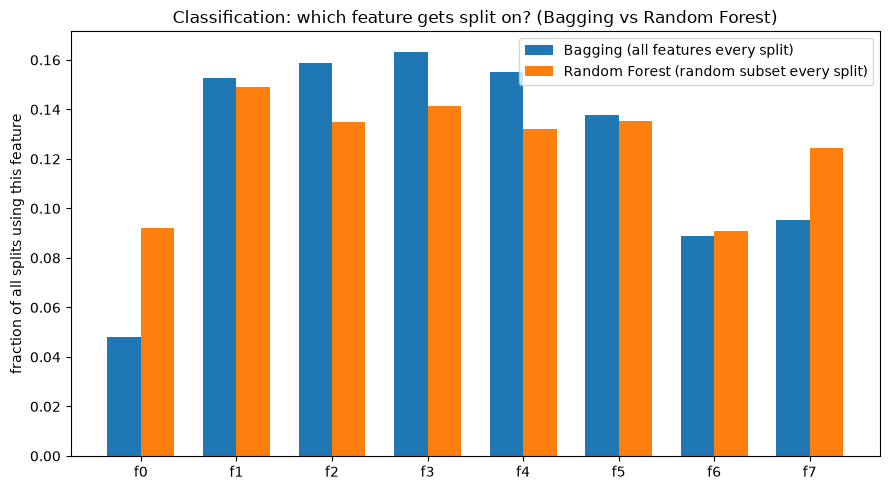

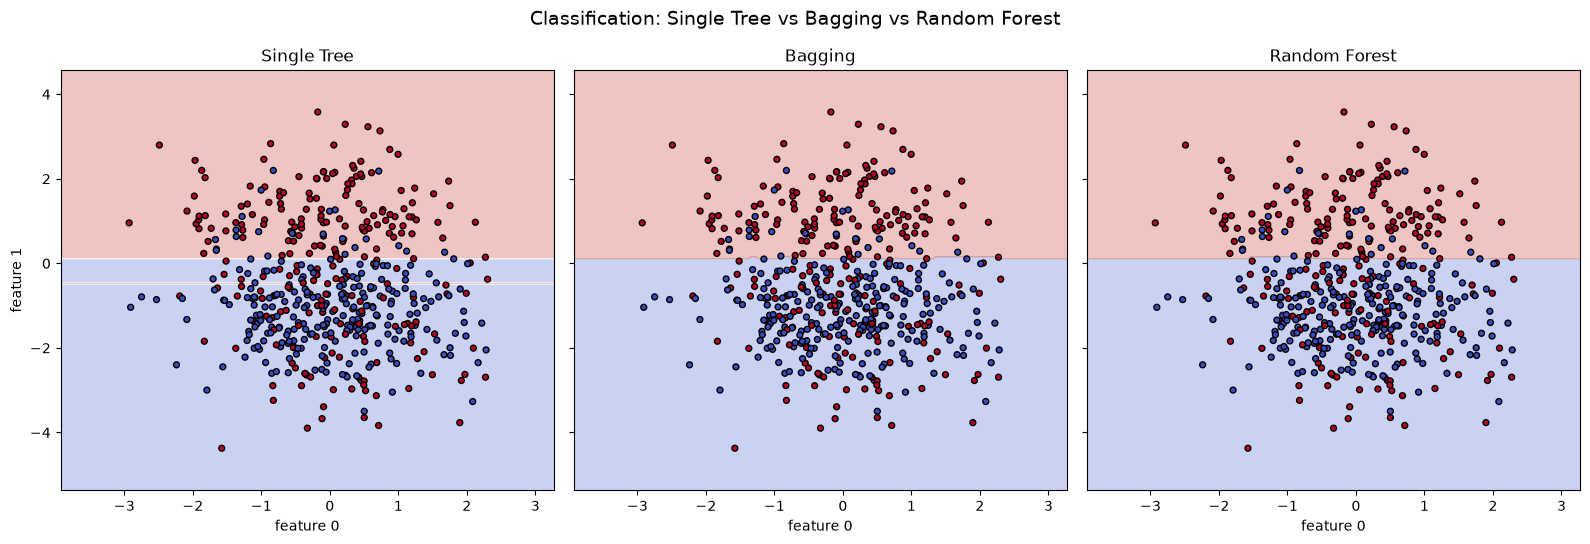

In [5]:

single_c = DecisionTreeClassifier(random_state=RANDOM_STATE)
bagging_c = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=N_ESTIMATORS, bootstrap=True, max_features=1.0,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_c = RandomForestClassifier(
    n_estimators=N_ESTIMATORS, bootstrap=True, max_features="sqrt",
    random_state=RANDOM_STATE, n_jobs=-1,
)

for name, model in [("Single Tree", single_c), ("Bagging", bagging_c), ("Random Forest", rf_c)]:
    scores = cross_val_score(model, Xc, yc, cv=CV_FOLDS, scoring="accuracy")
    print(f"  {name:15s} | CV accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")

bagging_c.fit(Xc, yc)
rf_c.fit(Xc, yc)
bag_usage_c = split_feature_usage(bagging_c, Xc.shape[1])
rf_usage_c = split_feature_usage(rf_c, Xc.shape[1])
plot_feature_usage(
    bag_usage_c, rf_usage_c,
    "Classification: which feature gets split on? (Bagging vs Random Forest)"
)
plot_classification_three_way(
    single_c, bagging_c, rf_c, Xc, yc, feat_idx=(0, 1),
    title="Classification: Single Tree vs Bagging vs Random Forest"
)

# Single Tree vs Bagging(Decision Tree) vs Random Forest Regressor

  Single Tree     | CV r2: 0.5358 +/- 0.0758
  Bagging         | CV r2: 0.8009 +/- 0.0219
  Random Forest   | CV r2: 0.7590 +/- 0.0163


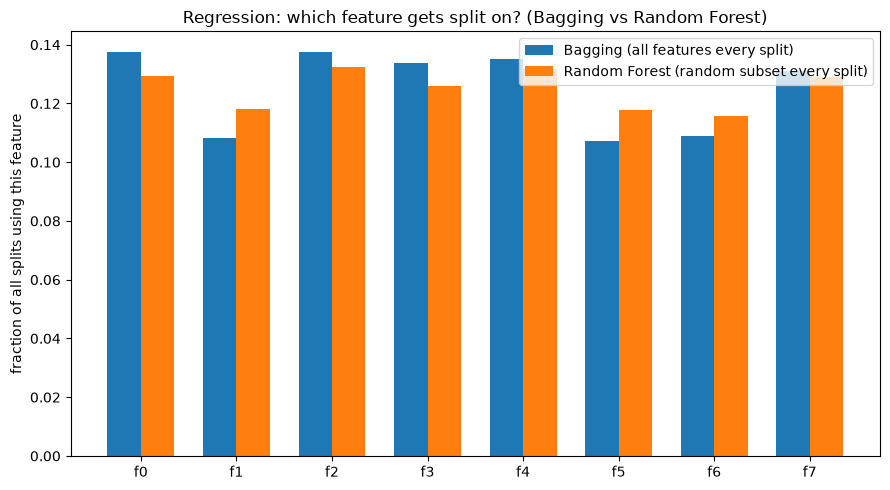

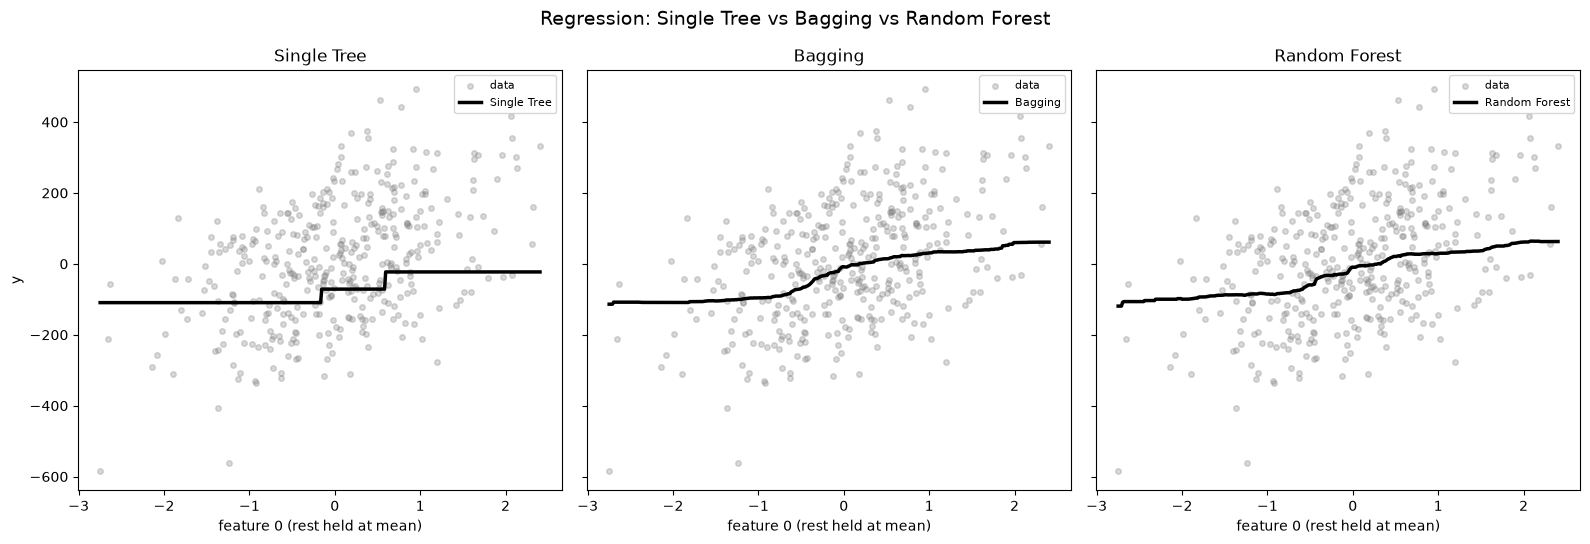

In [ ]:
single_r = DecisionTreeRegressor(random_state=RANDOM_STATE)
bagging_r = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    n_estimators=N_ESTIMATORS, bootstrap=True, max_features=1.0,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_r = RandomForestRegressor(
    n_estimators=N_ESTIMATORS, bootstrap=True, max_features="sqrt",
    random_state=RANDOM_STATE, n_jobs=-1,
)
 
for name, model in [("Single Tree", single_r), ("Bagging", bagging_r), ("Random Forest", rf_r)]:
    scores = cross_val_score(model, Xr, yr, cv=CV_FOLDS, scoring="r2")
    print(f"  {name:15s} | CV r2: {scores.mean():.4f} +/- {scores.std():.4f}")
 
bagging_r.fit(Xr, yr)
rf_r.fit(Xr, yr)
bag_usage_r = split_feature_usage(bagging_r, Xr.shape[1])
rf_usage_r = split_feature_usage(rf_r, Xr.shape[1])
plot_feature_usage(
    bag_usage_r, rf_usage_r,
    "Regression: which feature gets split on? (Bagging vs Random Forest)"
)
plot_regression_three_way(
    single_r, bagging_r, rf_r, Xr, yr, feat_idx=0,
    title="Regression: Single Tree vs Bagging vs Random Forest"
)

# Hyperparameter tuning 

In [7]:
param_dist_clf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False],
}

search_clf = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist_clf,
    n_iter=25, cv=CV_FOLDS, scoring="accuracy",
    random_state=RANDOM_STATE, n_jobs=-1,
)
search_clf.fit(Xc, yc)
print("\nClassifier:")
print(f"  Default RF CV accuracy : {cross_val_score(rf_c, Xc, yc, cv=CV_FOLDS, scoring='accuracy').mean():.4f}")
print(f"  Best CV accuracy       : {search_clf.best_score_:.4f}")
print(f"  Best params            : {search_clf.best_params_}")

param_dist_reg = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False],
}

search_reg = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist_reg,
    n_iter=25, cv=CV_FOLDS, scoring="r2",
    random_state=RANDOM_STATE, n_jobs=-1,
)
search_reg.fit(Xr, yr)
print("\nRegressor:")
print(f"  Default RF CV r2       : {cross_val_score(rf_r, Xr, yr, cv=CV_FOLDS, scoring='r2').mean():.4f}")
print(f"  Best CV r2             : {search_reg.best_score_:.4f}")
print(f"  Best params            : {search_reg.best_params_}")


Classifier:
  Default RF CV accuracy : 0.9420
  Best CV accuracy       : 0.9460
  Best params            : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}

Regressor:
  Default RF CV r2       : 0.7590
  Best CV r2             : 0.7985
  Best params            : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 20, 'bootstrap': True}


# OOB score

In [8]:
best_clf_params = dict(search_clf.best_params_)
best_clf_params["bootstrap"] = True
rf_oob_clf = RandomForestClassifier(
    oob_score=True, random_state=RANDOM_STATE, n_jobs=-1, **best_clf_params
)
rf_oob_clf.fit(Xc, yc)
cv_acc = cross_val_score(rf_oob_clf, Xc, yc, cv=CV_FOLDS, scoring="accuracy").mean()
 
print("\nClassifier:")
print(f"  OOB score (fit once)      : {rf_oob_clf.oob_score_:.4f}")
print(f"  5-fold CV accuracy (5x fit): {cv_acc:.4f}")
 
best_reg_params = dict(search_reg.best_params_)
best_reg_params["bootstrap"] = True
rf_oob_reg = RandomForestRegressor(
    oob_score=True, random_state=RANDOM_STATE, n_jobs=-1, **best_reg_params
)
rf_oob_reg.fit(Xr, yr)
cv_r2 = cross_val_score(rf_oob_reg, Xr, yr, cv=CV_FOLDS, scoring="r2").mean()
 
print("\nRegressor:")
print(f"  OOB score (fit once)      : {rf_oob_reg.oob_score_:.4f}")
print(f"  5-fold CV r2 (5x fit)     : {cv_r2:.4f}")


Classifier:
  OOB score (fit once)      : 0.9420
  5-fold CV accuracy (5x fit): 0.9460

Regressor:
  OOB score (fit once)      : 0.8277
  5-fold CV r2 (5x fit)     : 0.7985
